In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
# 安装必要库
!pip install albumentations opencv-python-headless matplotlib pyyaml -q

In [71]:
import os
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import albumentations as A
from shutil import copyfile

# 配置路径
DATASET_ROOT = '/content/drive/MyDrive/Colab Notebooks/s2/DSAI/final/construction safety.v2i.yolov8' # 你的数据集根目录
IMG_SIZE = 640           # 统一输入尺寸

✅ 类别分析路径: /content/drive/MyDrive/Colab Notebooks/s2/DSAI/final/construction safety.v2i.yolov8/train/labels 存在


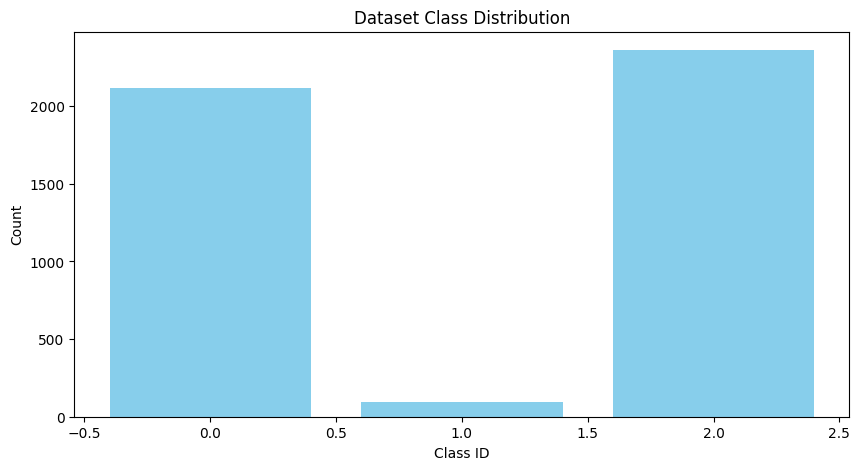

In [72]:
def check_path_exists(path, desc):
    """检查路径是否存在，打印调试信息"""
    if os.path.exists(path):
        print(f"✅ {desc}: {path} 存在")
        return True
    else:
        print(f"❌ {desc}: {path} 不存在")
        return False

def count_files(dir_path, ext):
    """统计指定目录下指定后缀的文件数量"""
    if not os.path.exists(dir_path):
        return 0
    files = glob(f"{dir_path}/*.{ext}")
    print(f"📂 {dir_path} 下.{ext} 文件数量: {len(files)}")
    return len(files)

# 分析类别分布
def analyze_classes(label_path):
    check_path_exists(label_path, "类别分析路径")
    labels = glob(f"{label_path}/*.txt")
    stats = {}
    for lb in labels:
        with open(lb, 'r') as f:
            for line in f:
                cls = int(line.split()[0])
                stats[cls] = stats.get(cls, 0) + 1

    # 绘制分布图
    plt.figure(figsize=(10, 5))
    plt.bar(stats.keys(), stats.values(), color='skyblue')
    plt.xlabel('Class ID')
    plt.ylabel('Count')
    plt.title('Dataset Class Distribution')
    plt.show()
    return stats

# 执行类别分析
stats = analyze_classes(f"{DATASET_ROOT}/train/labels")

In [73]:
# 定义增强策略
transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3), # 模拟传感器噪声
    A.MotionBlur(blur_limit=7, p=0.2),           # 模拟运动模糊
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def process_and_augment(img_dir, label_dir, output_img_dir, output_label_dir, aug_factor=2):
    # ========== 修复1：递归创建目录（确保父目录存在） ==========
    os.makedirs(output_img_dir, exist_ok=True, mode=0o755)
    os.makedirs(output_label_dir, exist_ok=True, mode=0o755)

    # 调试：打印输入输出路径
    print(f"\n📌 处理路径：")
    print(f"输入图片: {img_dir}")
    print(f"输入标签: {label_dir}")
    print(f"输出图片: {output_img_dir}")
    print(f"输出标签: {output_label_dir}")

    # ========== 修复2：支持多种图片格式（.jpg/.jpeg/.png） ==========
    img_paths = glob(f"{img_dir}/*.jpg") + glob(f"{img_dir}/*.jpeg") + glob(f"{img_dir}/*.png")
    print(f"🔍 找到 {len(img_paths)} 张图片")

    if len(img_paths) == 0:
        print("⚠️ 未找到任何图片，请检查输入路径！")
        return

    processed_count = 0
    skipped_count = 0

    for img_p in img_paths:
        fname = os.path.basename(img_p).replace('_jpg.jpg', '').replace('.jpg', '').replace('.png', '').replace('.jpeg', '')
        # ========== 修复3：容错图片读取 ==========
        image = cv2.imread(img_p)
        if image is None:
            print(f"⚠️ 无法读取图片: {img_p}，跳过")
            skipped_count += 1
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        lb_p = os.path.join(label_dir, f"{fname}.txt")
        if not os.path.exists(lb_p):
            print(f"⚠️ 标签文件不存在: {lb_p}，跳过")
            skipped_count += 1
            continue

        # 读取标签
        with open(lb_p, 'r') as f:
            lines = f.readlines()
        if len(lines) == 0:
            print(f"⚠️ 标签文件为空: {lb_p}，跳过")
            skipped_count += 1
            continue

        bboxes = []
        class_labels = []
        for line in lines:
            parts = list(map(float, line.split()))
            if len(parts) != 5: # YOLO格式必须是 类别 x y w h
                print(f"⚠️ 标签格式错误: {lb_p} 行: {line}，跳过")
                continue
            class_labels.append(int(parts[0]))
            bboxes.append(parts[1:]) # [x, y, w, h]

        if len(bboxes) == 0:
            print(f"⚠️ 无有效标签: {lb_p}，跳过")
            skipped_count += 1
            continue

        # 1. 保存原始图像（已 Resize）
        try:
            resized = A.Resize(IMG_SIZE, IMG_SIZE)(image=image)['image']
            resized_path = os.path.join(output_img_dir, f"{fname}.jpg")
            cv2.imwrite(resized_path, cv2.cvtColor(resized, cv2.COLOR_RGB2BGR))
            copyfile(lb_p, os.path.join(output_label_dir, f"{fname}.txt"))
        except Exception as e:
            print(f"❌ 保存原始文件失败: {e}，跳过")
            skipped_count += 1
            continue

        # 2. 生成增强图像
        for i in range(aug_factor):
            try:
                transformed = transform(image=image, bboxes=bboxes, class_labels=class_labels)
                aug_img = transformed['image']
                aug_bboxes = transformed['bboxes']

                # 保存增强后的图
                aug_fname = f"{fname}_aug_{i}"
                aug_img_path = os.path.join(output_img_dir, f"{aug_fname}.jpg")
                cv2.imwrite(aug_img_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

                # 保存对应的 YOLO 标签
                with open(os.path.join(output_label_dir, f"{aug_fname}.txt"), 'w') as f:
                    for cls, bbox in zip(class_labels, aug_bboxes):
                        f.write(f"{cls} {' '.join(map(str, bbox))}\n")
            except Exception as e:
                print(f"❌ 生成增强文件失败 {fname}_aug_{i}: {e}")
                continue

        processed_count += 1
        if processed_count % 10 == 0:
            print(f"🔄 已处理 {processed_count} 张图片...")

    # 输出统计
    print(f"\n📊 处理完成：")
    print(f"✅ 成功处理: {processed_count} 张图片")
    print(f"❌ 跳过: {skipped_count} 张图片")
    print(f"📂 输出图片数量: {count_files(output_img_dir, 'jpg')}")
    print(f"📂 输出标签数量: {count_files(output_label_dir, 'txt')}")


/tmp/ipykernel_9006/286063981.py:6: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3), # 模拟传感器噪声


In [74]:
def verify_labels(img_path, label_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"❌ 无法读取验证图片: {img_path}")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    with open(label_path, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) != 5:
                continue
            cls, x, y, bw, bh = map(float, parts)
            # 还原坐标
            x1, y1 = int((x - bw/2) * w), int((y - bh/2) * h)
            x2, y2 = int((x + bw/2) * w), int((y + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.imshow(img)
    plt.title("Augmentation Verification")
    plt.axis('off')
    plt.show()


📌 处理路径：
输入图片: /content/drive/MyDrive/Colab Notebooks/s2/DSAI/final/construction safety.v2i.yolov8/train/images
输入标签: /content/drive/MyDrive/Colab Notebooks/s2/DSAI/final/construction safety.v2i.yolov8/train/labels
输出图片: /content/drive/MyDrive/Colab Notebooks/s2/DSAI/final/construction safety.v2i.yolov8/train/processed/images
输出标签: /content/drive/MyDrive/Colab Notebooks/s2/DSAI/final/construction safety.v2i.yolov8/train/processed/labels
🔍 找到 997 张图片
🔄 已处理 10 张图片...
🔄 已处理 20 张图片...
🔄 已处理 30 张图片...
🔄 已处理 40 张图片...
🔄 已处理 50 张图片...
🔄 已处理 60 张图片...
🔄 已处理 70 张图片...
🔄 已处理 80 张图片...
🔄 已处理 90 张图片...
🔄 已处理 100 张图片...
🔄 已处理 110 张图片...
🔄 已处理 120 张图片...
🔄 已处理 130 张图片...
🔄 已处理 140 张图片...
🔄 已处理 150 张图片...
🔄 已处理 160 张图片...
🔄 已处理 170 张图片...
🔄 已处理 180 张图片...
🔄 已处理 190 张图片...
🔄 已处理 200 张图片...
🔄 已处理 210 张图片...
🔄 已处理 220 张图片...
🔄 已处理 230 张图片...
🔄 已处理 240 张图片...
🔄 已处理 250 张图片...
🔄 已处理 260 张图片...
🔄 已处理 270 张图片...
🔄 已处理 280 张图片...
🔄 已处理 290 张图片...
🔄 已处理 300 张图片...
🔄 已处理 310 张图片...
🔄 已处理 320 张图片...
🔄 已处理 330 张

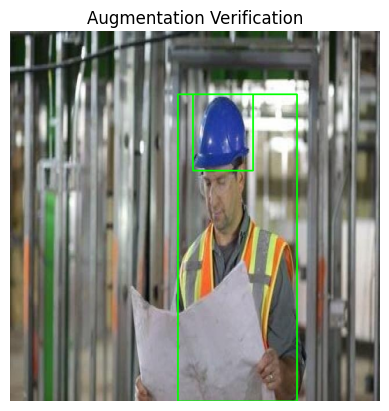

In [75]:
# ========== 运行预处理 ==========
# 处理训练集（增强2倍）
process_and_augment(
    img_dir=f"{DATASET_ROOT}/train/images",
    label_dir=f"{DATASET_ROOT}/train/labels",
    output_img_dir=f"{DATASET_ROOT}/train/processed/images",
    output_label_dir=f"{DATASET_ROOT}/train/processed/labels",
    aug_factor=2
)

# 处理验证集（仅Resize，不增强）
process_and_augment(
    img_dir=f"{DATASET_ROOT}/valid/images",
    label_dir=f"{DATASET_ROOT}/valid/labels",
    output_img_dir=f"{DATASET_ROOT}/valid/processed/images",
    output_label_dir=f"{DATASET_ROOT}/valid/processed/labels",
    aug_factor=0
)

# ========== 验证示例（可选） ==========
# 随机选一张处理后的图片验证
train_processed_img = glob(f"{DATASET_ROOT}/train/processed/images/*.jpg")
if len(train_processed_img) > 0:
    sample_img = train_processed_img[0]
    sample_label = os.path.join(
        f"{DATASET_ROOT}/train/processed/labels",
        os.path.basename(sample_img).replace('.jpg', '.txt')
    )
    if os.path.exists(sample_label):
        verify_labels(sample_img, sample_label)
    else:
        print(f"❌ 验证标签不存在: {sample_label}")
else:
    print("❌ 无处理后的图片可验证")